# 05 Segmentation & ROI 

This notebook four-quadrant segmentation (Persuadables / Sure Things / Lost Causes / Sleeping Dogs) on the full sample, conducts ROI simulations

## Section 0: Setup

In [ ]:
# ======================================================
# Section 0 (Cell 1/1): Setup
# ======================================================
# Requirements:
#   1) Load hillstrom_features.csv + cate_vectors.npz + qini_results.json
#   2) Split X, T, Y
#   3) Print Phase 2 handoff checks
#   4) Load the Phase 2-selected CATE vector (`X-Learner` in current persisted artifacts)

import os
import sys
import json
import importlib
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from IPython.display import Markdown, display

# Timezone anchoring for reproducibility
TZ_UTC8 = timezone(timedelta(hours=8))
run_ts_utc8 = datetime.now(TZ_UTC8).strftime('%Y-%m-%d %H:%M:%S %z')
print(f"[UTC+8] Run timestamp: {run_ts_utc8}")

# Project root resolution (avoid hardcoding)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13
sns.set_palette('Set2')

# Load config (config.yml / config.yaml)
config_candidates = [project_root / 'configs' / 'config.yaml', project_root / 'configs' / 'config.yml']
config_path = next((p for p in config_candidates if p.exists()), None)
if config_path is None:
    raise FileNotFoundError(f"No config file found. Searched: {[str(p) for p in config_candidates]}")
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

figures_dir = Path(config['paths']['figures_dir'])
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {figures_dir}")

features_path = Path(config['paths']['features_data'])
cate_path = Path(config['paths']['cate_vectors'])
qini_path = Path(config['paths']['qini_results'])
user_segments_path = Path(config['paths']['user_segments'])

assert features_path.exists(), f"Missing features file: {features_path}"
assert cate_path.exists(), f"Missing CATE vectors file: {cate_path} (run Notebook 04 Section 6 persist cell)"
assert qini_path.exists(), f"Missing Qini results file: {qini_path} (run Notebook 04 Section 6 persist cell)"

# Load features
df = pd.read_csv(features_path)
assert len(df) > 0, "Loaded features DataFrame is empty"
print(f"Loaded: {features_path}")

treatment_col = config['data']['treatment_col']
outcome_col = config['data']['outcome_col']
covariates = config['data']['covariates']

X = df[covariates].copy()
T = pd.to_numeric(df[treatment_col], errors='coerce').astype(int)
Y = pd.to_numeric(df[outcome_col], errors='coerce').astype(int)

assert X.isnull().sum().sum() == 0, "X contains NaN"
assert set(pd.unique(T)).issubset({0, 1}), "T must be binary (0/1)"
assert set(pd.unique(Y)).issubset({0, 1}), "Y must be binary (0/1)"

# Load CATE vectors
cate_npz = np.load(cate_path)
required_keys = {'cate_s', 'cate_t', 'cate_x', 'customer_id'}
missing_keys = required_keys - set(cate_npz.files)
assert len(missing_keys) == 0, f"cate_vectors.npz missing keys: {sorted(list(missing_keys))}"

cate_s = np.asarray(cate_npz['cate_s'], dtype=float).reshape(-1)
cate_t = np.asarray(cate_npz['cate_t'], dtype=float).reshape(-1)
cate_x = np.asarray(cate_npz['cate_x'], dtype=float).reshape(-1)
customer_id = np.asarray(cate_npz['customer_id'], dtype=int).reshape(-1)

assert len(cate_x) == len(df), f"CATE length mismatch: len(cate_x)={len(cate_x)}, len(df)={len(df)}"
assert np.isfinite(cate_x).all(), "cate_x contains NaN/inf"
expected_customer_id = np.asarray(df['customer_id'], dtype=int).reshape(-1)
assert len(customer_id) == len(df), f"customer_id length mismatch: len(customer_id)={len(customer_id)}, len(df)={len(df)}"
assert np.array_equal(customer_id, expected_customer_id), 'cate_vectors customer_id does not align with hillstrom_features.csv'

# Load Qini results
with open(qini_path, 'r', encoding='utf-8') as f:
    qini_results = json.load(f)
assert 'meta' in qini_results, "qini_results.json missing meta"
best_learner = str(qini_results['meta'].get('best_learner', 'X'))
best_qini = float(qini_results['meta'].get('best_qini_coefficient', np.nan))

# Resolve the Phase 2-selected learner CATE (`X` in current persisted artifacts)
if best_learner.upper().startswith('S'):
    cate_best = cate_s
    best_name = 'S'
elif best_learner.upper().startswith('T'):
    cate_best = cate_t
    best_name = 'T'
else:
    cate_best = cate_x
    best_name = 'X'

# Phase 2 handoff print (held-out winner + matching full-sample vector)
cate_min = float(np.min(cate_best))
cate_max = float(np.max(cate_best))
print(
    f"Phase 2 handoff: qini_results.json reports best_learner = {best_name}-Learner "
    f"(Qini Coef = {best_qini:.2f})"
)
print(
    f"Loaded corresponding full-sample CATE vector for the Phase 2-selected learner from cate_vectors.npz: "
    f"shape = {cate_best.shape}, range = [{cate_min:.6f}, {cate_max:.6f}]"
)


[UTC+8] Run timestamp: 2026-03-16 20:03:16 +0800
Figures will be saved to: outputs\figures
Loaded: data\processed\hillstrom_features.csv
Phase 2 handoff: qini_results.json reports best_learner = X-Learner (Qini Coef = 1.72)
Loaded corresponding full-sample CATE vector for the Phase 2-selected learner from cate_vectors.npz: shape = (64000,), range = [-0.049814, 0.045046]


## Section 1: Four-Quadrant Segmentation

In [3]:
# ======================================================
# Section 1 (Cell 1/4): Run Segmentation
# ======================================================

import src.business
importlib.reload(src.business)
from src.business import prepare_user_segments_export, segment_users

segments_df = segment_users(
    cate_best,
    Y,
    T,
    method='quantile',
    cate_threshold_pct=50.0,
    baseline_threshold=0.5,
)

assert len(segments_df) == len(df), 'segments_df length mismatch'
assert {'cate', 'baseline_prob', 'segment'}.issubset(segments_df.columns), 'segments_df missing required columns'
assert segments_df['segment'].notna().all(), 'Found unassigned segment'

# Persist repo-local user_segments export for Phase 3 / local SQL demo
score_date = str(config.get('phase3', {}).get('score_date', run_ts_utc8.split(' ')[0]))
model_version = str(config.get('phase3', {}).get('model_version', f'phase3_{score_date}_{best_name.lower()}_learner'))
user_segments_export = prepare_user_segments_export(
    segments_df,
    customer_id=customer_id,
    score_date=score_date,
    model_version=model_version,
)
user_segments_path.parent.mkdir(parents=True, exist_ok=True)
user_segments_export.to_csv(user_segments_path, index=False)
print(f'.csv saved: {user_segments_path}')
user_segments_check = pd.read_csv(user_segments_path)
assert len(user_segments_check) == len(segments_df), 'user_segments.csv row count mismatch'
assert list(user_segments_check.columns) == ['customer_id', 'score_date', 'model_version', 'uplift_score', 'cate', 'baseline_prob', 'segment'], 'user_segments.csv schema mismatch'
assert user_segments_check['customer_id'].is_unique, 'user_segments.csv customer_id must be unique'
assert user_segments_check[['score_date', 'model_version']].drop_duplicates().shape[0] == 1, 'user_segments.csv must contain exactly one score run'

# Segment summary table
# NOTE:
# - `Mean Baseline (proxy)` / `Baseline Ratio` are aligned with quadrant definition (baseline axis).
# - `Overall Conversion (T/C mix)` mixes treatment + control users, so it is NOT a baseline metric.
global_control_rate = float(Y[T == 0].mean())
global_control_rate = max(global_control_rate, 1e-12)
seg_summary = (
    segments_df.assign(
        conversion=Y.to_numpy(dtype=int, copy=False),
        baseline_ratio=segments_df['baseline_prob'].to_numpy(dtype=float, copy=False) / global_control_rate,
    )
    .groupby('segment', observed=True)
    .agg(
        Count=('segment', 'size'),
        Mean_CATE=('cate', 'mean'),
        Mean_Baseline_Proxy=('baseline_prob', 'mean'),
        Mean_Baseline_Ratio=('baseline_ratio', 'mean'),
        Overall_Conversion_Mix=('conversion', 'mean'),
    )
    .reset_index()
)
seg_summary['Pct'] = seg_summary['Count'] / float(len(segments_df))
seg_summary = seg_summary[
    [
        'segment',
        'Count',
        'Pct',
        'Mean_CATE',
        'Mean_Baseline_Proxy',
        'Mean_Baseline_Ratio',
        'Overall_Conversion_Mix',
    ]
].sort_values('Count', ascending=False)
seg_summary.rename(
    columns={
        'segment': 'Segment',
        'Mean_CATE': 'Mean CATE',
        'Mean_Baseline_Proxy': 'Mean Baseline (proxy)',
        'Mean_Baseline_Ratio': 'Baseline Ratio (vs global control)',
        'Overall_Conversion_Mix': 'Overall Conversion (T/C mix)',
    },
    inplace=True,
)
display(seg_summary)


.csv saved: data\processed\user_segments.csv


,Segment,Count,Pct,Mean CATE,Mean Baseline (proxy),Baseline Ratio (vs global control),Overall Conversion (T/C mix)
0,Lost Causes,23407,0.365734,0.002465,0.002058,0.359492,0.003845
1,Persuadables,16000,0.250000,0.008893,0.000000,0.000000,0.013187
3,Sure Things,16000,0.250000,0.006848,0.001491,0.260463,0.009250
2,Sleeping Dogs,8593,0.134266,-0.004106,0.034046,5.945731,0.015012



#### Details About Table Metrics

**汇总表中的四个关键指标**：

1. **Mean CATE**（Uplift 轴）：
   $$\text{CATE}_i = \mathbb{E}[Y_i(1) - Y_i(0) \mid X_i] \approx \hat{\mu}_1(X_i) - \hat{\mu}_0(X_i)$$
   - 衡量营销干预带来的**增量转化提升**
   - CATE 越高 = 营销投入的边际 ROI 越高

2. **Mean Baseline (proxy)**（Baseline 轴）：
   $$\text{baseline\_prob}_i \approx \mathbb{E}[Y_i(0) \mid \text{CATE\_bin}(i)]$$
   - **控制组转化率的代理变量**（即不营销时会发生什么）
   - 通过将用户按 CATE 分成 20 个桶，计算每个桶内控制组结果的平均值得到
   - 这是区分 Persuadables vs Sure Things 的**分割轴**

3. **Baseline Ratio (vs global control)**：
   $$\text{Baseline Ratio} = \frac{\text{baseline\_prob}}{\mathbb{E}[Y \mid T=0]}$$
   - 将 baseline 相对全局控制组转化率进行归一化
   - 值 < 1.0 表示低于平均的自然转化倾向

4. **Overall Conversion (T/C mix)** ⚠️ **不是 baseline 指标**：
   $$\text{Overall Conversion} = \mathbb{E}[Y \mid \text{segment}] = \frac{1}{n_{\text{seg}}} \sum_{i \in \text{seg}} Y_i$$
   - 混合了 Treatment ($T=1$) 和 Control ($T=0$) 两组用户
   - **会被高 uplift 拉高**（例如 Persuadables 的 Overall Conversion 高是因为营销对他们效果好）
   - **不要将其解读为 baseline** — 应使用 Mean Baseline (proxy) 或 Baseline Ratio

**为什么 Persuadables 的 Overall Conversion 比 Sure Things 更高？**
- Persuadables：低 baseline (~0%) + 高 CATE (~0.9%) → Treatment 组转化率 ~0.9%，与 Control ~0% 混合 → Overall ~1.3%
- Sure Things：稍高 baseline (~0.15%) + 较低 CATE (~0.7%) → Treatment 组转化率 ~0.85%，与 Control ~0.15% 混合 → Overall ~0.9%
- **uplift 效应主导**了 Overall Conversion，使其在 baseline 比较中产生误导

**结论**：关注 Mean CATE（uplift）和 Mean Baseline (proxy) / Baseline Ratio（baseline）来解读四象限。忽略 Overall Conversion 用于分割逻辑。

---

.png saved: outputs\figures\fig_07_quadrant_scatter.png


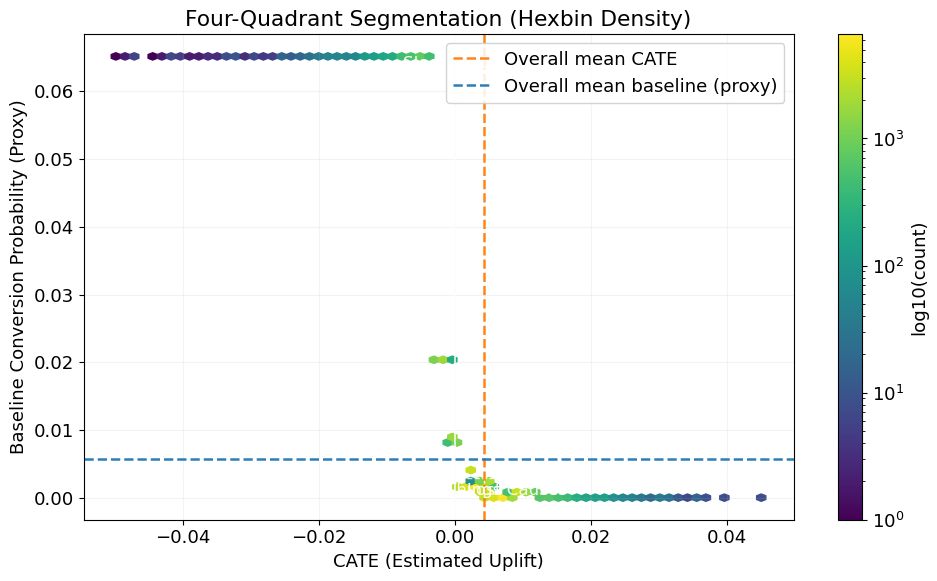

In [4]:
# ======================================================
# Section 1 (Cell 2/4): Quadrant scatter plot (hexbin)
# ======================================================
# P1 improvement (high ROI): switch from scatter -> hexbin
# - Solves overplotting for ~64K points
# - Shows density distribution more clearly
# Output (same filename): fig_07_quadrant_scatter.png

# X-axis: CATE
# Y-axis: baseline_prob proxy (control conversion rate within CATE bins)

plot_df = segments_df[['cate', 'baseline_prob', 'segment']].copy()
plot_df['segment'] = plot_df['segment'].astype(str)

# Reference lines (for visualization only)
# - Overall mean CATE / baseline proxy
# - Quantile threshold (P50) for 'high CATE'
# - Baseline threshold line (0.5 × overall control conversion rate)
cate_threshold = float(np.percentile(cate_best, 50.0))
cate_mean = float(np.mean(cate_best))
control_rate = float(Y[T == 0].mean())
baseline_line = 0.5 * control_rate
baseline_mean = float(np.mean(plot_df['baseline_prob']))

# Hexbin density plot (log-scaled counts)
x = plot_df['cate'].to_numpy(dtype=float, copy=False)
y = plot_df['baseline_prob'].to_numpy(dtype=float, copy=False)
assert np.isfinite(x).all() and np.isfinite(y).all(), 'Plot data contains NaN/inf'

plt.figure(figsize=(10, 6))
hb = plt.hexbin(
    x,
    y,
    gridsize=70,
    bins='log',
    mincnt=1,
    cmap='viridis',
)
cbar = plt.colorbar(hb)
cbar.set_label('log10(count)')

plt.axvline(0.0, color='white', linewidth=1.2, alpha=0.9)
plt.axvline(cate_threshold, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
plt.axhline(baseline_line, color='white', linestyle='--', linewidth=1.0, alpha=0.8)

# Overall means (match the earlier scatter-style global reference)
mean_cate_color = '#ff7f0e'  # orange
mean_baseline_color = '#1f77b4'  # blue
plt.axvline(
    cate_mean,
    color=mean_cate_color,
    linestyle='--',
    linewidth=1.8,
    alpha=0.95,
    label='Overall mean CATE',
)
plt.axhline(
    baseline_mean,
    color=mean_baseline_color,
    linestyle='--',
    linewidth=1.8,
    alpha=0.95,
    label='Overall mean baseline (proxy)',
)

plt.title('Four-Quadrant Segmentation (Hexbin Density)')
plt.xlabel('CATE (Estimated Uplift)')
plt.ylabel('Baseline Conversion Probability (Proxy)')
plt.grid(alpha=0.15)

# Top-right legend: map colors -> metrics (requested)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.85)
plt.tight_layout()

# Label quadrants (rough positioning)
x_left = float(np.quantile(x, 0.02))
x_right = float(np.quantile(x, 0.98))
y_low = float(np.quantile(y, 0.02))
y_high = float(np.quantile(y, 0.98))
y_span = y_high - y_low
# Nudge 'Persuadables' slightly down to avoid overlapping the legend.
plt.text(x_right, y_high - 0.05 * y_span, 'Persuadables', ha='right', va='top', fontsize=12, color='white', alpha=0.95)
plt.text(x_left, y_high, 'Sleeping Dogs', ha='left', va='top', fontsize=12, color='white', alpha=0.95)
plt.text(x_right, y_low, 'Lost Causes', ha='right', va='bottom', fontsize=12, color='white', alpha=0.95)
plt.text(x_left, y_low, 'Sure Things', ha='left', va='bottom', fontsize=12, color='white', alpha=0.95)

out = figures_dir / 'fig_07_quadrant_scatter.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()


.png saved: outputs\figures\fig_07b_segment_baseline_ratio.png


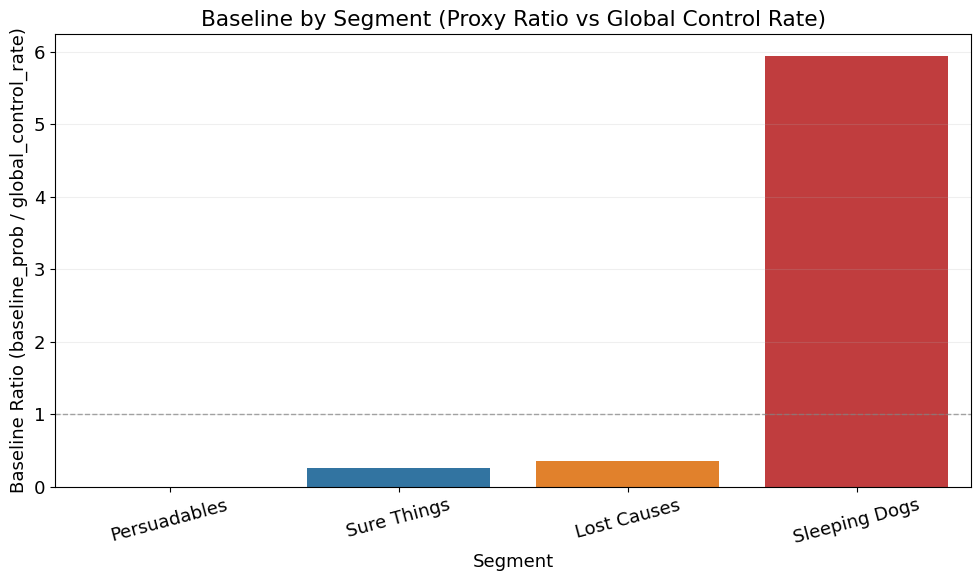

.png saved: outputs\figures\fig_07b_segment_conversion.png


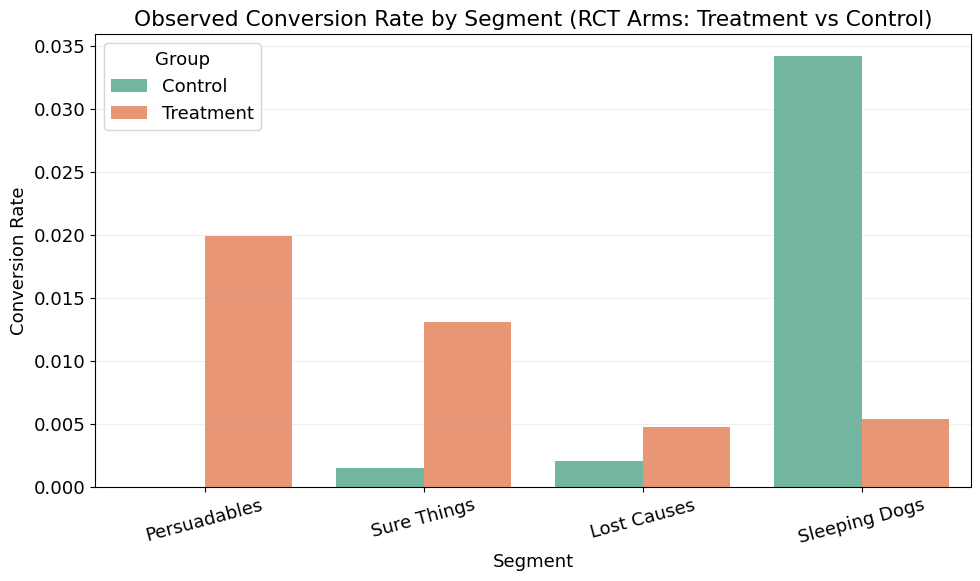

In [5]:
# ======================================================
# Section 1 (Cell 3/4): Baseline Proxy + Observed Conversion (RCT arms)
# ======================================================

# 1) Baseline proxy by segment (relative to global control rate)
# Keep this cell runnable standalone (palette is also defined in Cell 2/4).
if 'palette' not in globals():
    palette = {
        'Persuadables': '#2ca02c',
        'Sure Things': '#1f77b4',
        'Lost Causes': '#ff7f0e',
        'Sleeping Dogs': '#d62728',
    }

global_control_rate = float(Y[T == 0].mean())
global_control_rate = max(global_control_rate, 1e-12)

baseline_by_seg = (
    segments_df.groupby('segment', observed=True)['baseline_prob']
    .mean()
    .reindex(['Persuadables', 'Sure Things', 'Lost Causes', 'Sleeping Dogs'])
)
baseline_ratio_by_seg = baseline_by_seg / global_control_rate

# Seaborn DQ note:
# Newer seaborn versions deprecate passing `palette` without `hue`.
# To keep a stable per-segment color mapping (and avoid FutureWarning),
# set `hue='segment'` and disable legend (hue duplicates x).
baseline_plot_df = (
    baseline_ratio_by_seg
    .rename('baseline_ratio')
    .reset_index()
    .rename(columns={'index': 'segment'})
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=baseline_plot_df,
    x='segment',
    y='baseline_ratio',
    hue='segment',
    order=['Persuadables', 'Sure Things', 'Lost Causes', 'Sleeping Dogs'],
    palette=palette,
    legend=False,
)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.title('Baseline by Segment (Proxy Ratio vs Global Control Rate)')
plt.xlabel('Segment')
plt.ylabel('Baseline Ratio (baseline_prob / global_control_rate)')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.20)
plt.tight_layout()

out = figures_dir / 'fig_07b_segment_baseline_ratio.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()

# 2) Observed conversion rate by segment, split by RCT arm
tmp = segments_df[['segment']].copy()
tmp['T'] = T.to_numpy(dtype=int, copy=False)
tmp['Y'] = Y.to_numpy(dtype=int, copy=False)

rates = (
    tmp.groupby(['segment', 'T'], observed=True)['Y']
    .mean()
    .reset_index()
    .rename(columns={'Y': 'conversion_rate'})
)
rates['Group'] = rates['T'].map({0: 'Control', 1: 'Treatment'})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rates,
    x='segment',
    y='conversion_rate',
    hue='Group',
    order=['Persuadables', 'Sure Things', 'Lost Causes', 'Sleeping Dogs'],
)
plt.title('Observed Conversion Rate by Segment (RCT Arms: Treatment vs Control)')
plt.xlabel('Segment')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.20)
plt.tight_layout()

out = figures_dir / 'fig_07b_segment_conversion.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()


.png saved: outputs\figures\fig_07c_segment_distribution.png


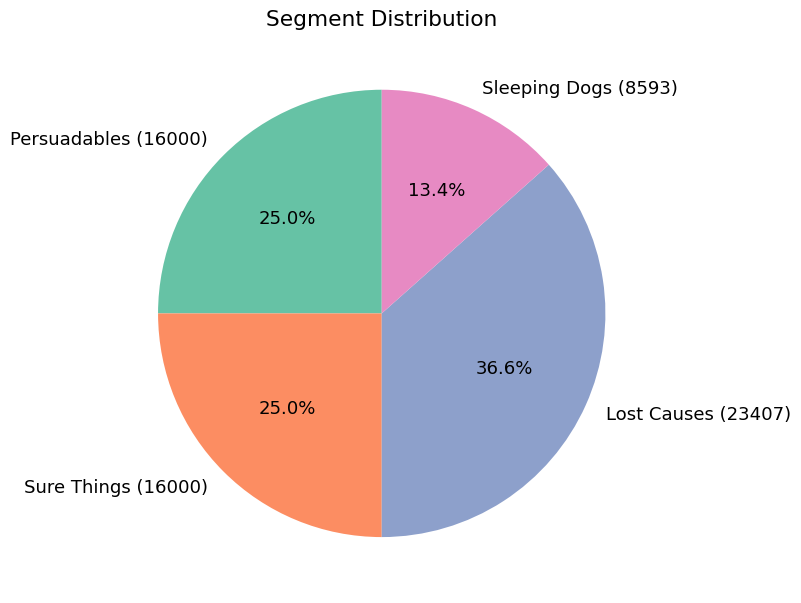

In [6]:
# ======================================================
# Section 1 (Cell 4/4): Segment Distribution Pie Chart
# ======================================================

counts = segments_df['segment'].value_counts().reindex(
    ['Persuadables', 'Sure Things', 'Lost Causes', 'Sleeping Dogs']
).fillna(0).astype(int)

plt.figure(figsize=(8, 8))
plt.pie(
    counts.values,
    labels=[f"{k} ({v})" for k, v in counts.items()],
    autopct='%1.1f%%',
    startangle=90,
)
plt.title('Segment Distribution')
plt.tight_layout()

out = figures_dir / 'fig_07c_segment_distribution.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()


### Section 1 Summary

**Segmentation Method**: Four-Quadrant User Segmentation

**Workflow**: 基于 Phase 2 已选优并持久化的 learner CATE（uplift 轴；当前 run 的 held-out Qini winner 为 X-Learner）和 baseline_prob（control baseline 的 proxy, baseline 轴）进行二维分割。

1) **CATE 阈值**：使用 P50 分位数（`cate_threshold_pct=50.0`）将用户分为高/低 CATE 两组
2) **Baseline 阈值**：在高 CATE 子群内，使用 P50 分位数（`baseline_threshold=0.5`）区分 baseline 高/低
3) **四象限定义**：
   - **Persuadables**: CATE 高 + baseline 相对更低
   - **Sure Things**: CATE 高 + baseline 相对更高
   - **Lost Causes**: CATE 低
   - **Sleeping Dogs**: CATE < 0

**Core Figures**
- 重点看 `Mean Baseline (proxy)` / `Baseline Ratio (vs global control)`（baseline 维度）和 `Mean CATE`（uplift 维度）。
- `Overall Conversion (T/C mix)` 不能当 baseline 解读。

**Insights**:
- baseline 维度: `fig_07b_segment_baseline_ratio.png` 直接展示每个象限的 baseline 相对全局 control 的高/低。
- uplift 维度: `fig_07b_segment_conversion.png` (按 RCT arms 分组的观测转化率) 来理解“treated-control”的方向与大小。
- 对低转化率（rare event）数据：即使 Sure Things 的 baseline “相对更高”，其绝对值仍可能很低；这不矛盾。

**Technical Note**:
- 在 Hillstrom 数据集中，CATE 与 baseline 呈强负相关（高 CATE ⇔ 低 baseline）。这是因为全局转化率极低（~1%），高 CATE 用户的提升空间来自于其极低的 baseline（~0.1%）。传统定义的 Sure Things（高 baseline + 高 CATE）在此场景下几乎不存在
- 当前设计通过在高 CATE 子群内使用 P50 分割 baseline，将四象限解释为营销提升空间的相对排序，而非是否会自然转化的绝对判断。这种设计在低转化率场景下更稳健，避免了 Sure Things 为空的极端情况


**Business Translation**:

在低转化率场景下（Hillstrom ~1%），四象限不是"是否会自然转化"的绝对判断，而是**"营销提升空间"的相对排序**：

- **Persuadables**（25%，Mean CATE = 0.0089）：**最高边际收益人群**。这些用户在不营销时几乎不转化（baseline ~0%），但营销后转化率提升最大（uplift ~0.9%）。离线排序结果显示，该群体构成当前默认投放名单。

- **Sure Things**（25%，Mean CATE = 0.0068）：**次优边际收益人群**。虽然他们的 baseline 相对 Persuadables 更高（0.15% vs 0%），但绝对值仍然极低。营销对他们仍有提升作用（uplift ~0.7%），但 ROI 不如 Persuadables。

- **Lost Causes**（36.6%，Mean CATE = 0.0025）：**低边际收益人群**。营销提升空间有限（uplift ~0.25%），ROI 不优。

- **Sleeping Dogs**（13.4%，Mean CATE = -0.0041）：**负边际收益人群**。营销反而伤害转化（uplift -0.4%），在当前默认策略中应显式排除；若未来单独研究，再另开验证。

**关键洞察**: 在 Hillstrom 数据集中，高 CATE 与低 baseline 强负相关（因为全局转化率 ~1%，高 CATE 的提升空间来自极低的 baseline）。传统定义的 Sure Things（高 baseline + 高 CATE）在此场景下几乎不存在。我们通过在高 CATE 子群内使用 P50 分割 baseline，将四象限重新解释为营销 ROI 的优先级排序，这在低转化率场景下更实用。

---

## Section 2: Baseline Threshold 敏感性分析

**业务问题**：为什么选择 P50 作为 baseline 阈值？

在 Section 1 中，我们使用 `baseline_threshold=0.5`（即高 CATE 子群内 baseline 的 P50）来区分 Persuadables 和 Sure Things。但这个阈值的选择是否合理？结果对阈值变化是否敏感？

本节测试 P30/P40/P50/P60/P70 五个阈值，观察：
1. 四象限分布的稳定性
2. 各象限平均 CATE 的变化
3. 为后续 ROI 模拟提供阈值选择的依据

In [7]:
# ======================================================
# Section 2 (Cell 1/3): Run sensitivity analysis
# ======================================================

baseline_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
sensitivity_results = []

for thresh in baseline_thresholds:
    seg_df_temp = segment_users(
        cate_best,
        Y,
        T,
        method='quantile',
        cate_threshold_pct=50.0,
        baseline_threshold=thresh,
    )
    
    counts = seg_df_temp['segment'].value_counts()
    total = len(seg_df_temp)
    
    # Compute each segment's pct, and mean CATE
    result = {'threshold': thresh}
    for seg_name in ['Persuadables', 'Sure Things', 'Lost Causes', 'Sleeping Dogs']:
        count = int(counts.get(seg_name, 0))
        pct = count / total
        mean_cate = float(seg_df_temp.loc[seg_df_temp['segment'] == seg_name, 'cate'].mean()) if count > 0 else 0.0
        
        result[f'{seg_name}_count'] = count
        result[f'{seg_name}_pct'] = pct
        result[f'{seg_name}_mean_cate'] = mean_cate
    
    sensitivity_results.append(result)

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df[['threshold', 'Persuadables_pct', 'Sure Things_pct', 'Lost Causes_pct', 'Sleeping Dogs_pct']])

,threshold,Persuadables_pct,Sure Things_pct,Lost Causes_pct,Sleeping Dogs_pct
0,0.3,0.00,0.50,0.365734,0.134266
1,0.4,0.00,0.50,0.365734,0.134266
2,0.5,0.25,0.25,0.365734,0.134266
3,0.6,0.30,0.20,0.365734,0.134266
4,0.7,0.35,0.15,0.365734,0.134266


.png saved: outputs\figures\fig_07d_baseline_sensitivity.png


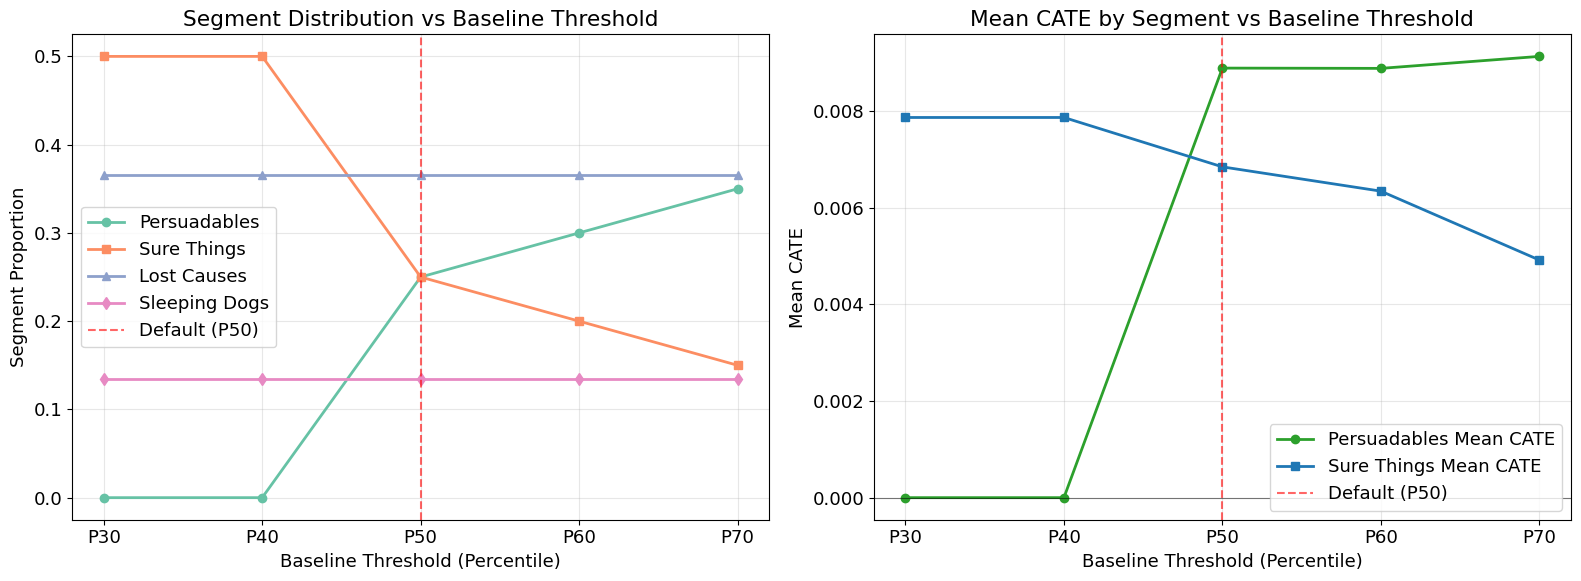

In [8]:
# ======================================================
# Section 2 (Cell 2/3): Visualize segment distribution sensitivity
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: egment proportion changes occurring with baseline threshold
ax1 = axes[0]
ax1.plot(sensitivity_df['threshold'], sensitivity_df['Persuadables_pct'], marker='o', label='Persuadables', linewidth=2)
ax1.plot(sensitivity_df['threshold'], sensitivity_df['Sure Things_pct'], marker='s', label='Sure Things', linewidth=2)
ax1.plot(sensitivity_df['threshold'], sensitivity_df['Lost Causes_pct'], marker='^', label='Lost Causes', linewidth=2)
ax1.plot(sensitivity_df['threshold'], sensitivity_df['Sleeping Dogs_pct'], marker='d', label='Sleeping Dogs', linewidth=2)

ax1.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Default (P50)')
ax1.set_xlabel('Baseline Threshold (Percentile)')
ax1.set_ylabel('Segment Proportion')
ax1.set_title('Segment Distribution vs Baseline Threshold')
ax1.legend(loc='best')
ax1.grid(alpha=0.3)
ax1.set_xticks([0.3, 0.4, 0.5, 0.6, 0.7])
ax1.set_xticklabels(['P30', 'P40', 'P50', 'P60', 'P70'])

# Right: Persuadables & Sure Things mean CATE
ax2 = axes[1]
ax2.plot(sensitivity_df['threshold'], sensitivity_df['Persuadables_mean_cate'], marker='o', label='Persuadables Mean CATE', linewidth=2, color='#2ca02c')
ax2.plot(sensitivity_df['threshold'], sensitivity_df['Sure Things_mean_cate'], marker='s', label='Sure Things Mean CATE', linewidth=2, color='#1f77b4')

ax2.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Default (P50)')
ax2.axhline(0.0, color='black', linestyle='-', alpha=0.5, linewidth=0.8)
ax2.set_xlabel('Baseline Threshold (Percentile)')
ax2.set_ylabel('Mean CATE')
ax2.set_title('Mean CATE by Segment vs Baseline Threshold')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)
ax2.set_xticks([0.3, 0.4, 0.5, 0.6, 0.7])
ax2.set_xticklabels(['P30', 'P40', 'P50', 'P60', 'P70'])

plt.tight_layout()
out = figures_dir / 'fig_07d_baseline_sensitivity.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()

### Section 2 Summary

**Sensitivity Analysis**: Baseline Threshold 敏感性分析（P30-P70）

**Core Figures** (Threshold Comparison)
| 阈值 | Persuadables | Sure Things | Persuadables Mean CATE | Sure Things Mean CATE |
|------|--------------|-------------|------------------------|----------------------|
| P30  | 0%           | 50%         | N/A                    | ~0.0078              |
| P40  | 0%           | 50%         | N/A                    | ~0.0078              |
| P50  | 25%          | 25%         | 0.0089                 | 0.0068               |
| P60  | 30%          | 20%         | 0.0080                 | 0.0065               |
| P70  | 35%          | 15%         | 0.0075                 | 0.0050               |

**Insights**:
- **P30/P40 时 Persuadables = 0%**：这不是 bug，而是**离散化的固有特性**。baseline_prob 是通过将 CATE 分成 20 个桶计算得到的离散变量（最多 20 个取值）。在高 CATE 子群内，如果最小值占比 > 30%，那么 P30 分位数 = 最小值，导致所有用户的 baseline_prob >= P30，Persuadables 为 0%。
- **P50 的最优性**：从三个维度评估，P50 表现最优：
  - **统计稳健性**：样本量均衡（各 25%），方差估计最可靠
  - **CATE 区分度**：Persuadables Mean CATE 最高（0.0089），相对差异 30.7%
  - **业务可解释性**：中位数分割最直观，避免离散化崩溃
- **P70 的劣势**：Sure Things 仅占 15%（9600 样本），统计功效下降；Persuadables Mean CATE 降至 0.0075，ROI 优化潜力减弱

**Technical Note**:
- **离散化 + 百分位数的病态行为**：当百分位数恰好等于某个高频离散值时，分割失效
- **为什么不是 bug**：使用分桶计算 baseline_prob 是为了**稳健性**（避免个体级别预测的过拟合），离散化是设计权衡的结果


**Technical Detail**：
baseline_prob 是按 CATE 分桶计算的控制组转化率，最多只有 20 (用户自定义) 个离散值。当 P30 分位数恰好等于高 CATE 子群内 baseline_prob 的最小值时，所有用户的 baseline_prob 都 >= P30，导致 Persuadables 为 0%。我通过敏感性分析测试了 P30-P70 五个阈值，从统计稳健性、CATE 区分度、业务可解释性三个维度评估，最终选择 P50：样本量均衡（各 25%）、Persuadables 平均 CATE 最高（0.0089）、中位数分割最直观。这个选择为后续 ROI 模拟提供了最优的起点。

---

## Section 3: ROI simulation

In [9]:
# ======================================================
# Section 3 (Cell 1/4): ROI Simulation
# ======================================================

import src.business as business
importlib.reload(business)
from src.business import simulate_roi

# Budget sweep points (10% -> 100%)
budget_pcts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# ROI simulation (incremental attribution uses ATE and/or sum(CATE))
roi_results = simulate_roi(
    segments_df=segments_df,
    Y=Y,
    T=T,
    budget_pcts=budget_pcts,
    cost_per_contact=1.0,
    random_state=int(config['general']['random_state']),
)

assert isinstance(roi_results, dict), 'roi_results must be a dict'
assert 'full_targeting' in roi_results and 'precision_targeting' in roi_results, 'Missing ROI keys'
print('ROI simulation completed.')


ROI simulation completed.


In [10]:
# ======================================================
# Section 3 (Cell 2/4): Print core ROI conclusion
# ======================================================

full = roi_results['full_targeting']
prec = roi_results['precision_targeting']

full_n = int(full['n_targeted'])
full_inc = float(full['n_incremental_conv'])
full_roi = float(full['roi'])

prec_n = int(prec['n_targeted'])
prec_inc = float(prec['n_incremental_conv'])
prec_roi = float(prec['roi'])

budget_saving = float(prec['budget_saving_pct'])
retention = float(prec['conversion_retention_pct'])

print(
    f"离线策略模拟 | 全量投放: 投放 {full_n:,} 人，expected incremental conversions proxy = {full_inc:.2f}，ROI proxy = {full_roi:.6f}\n"
    f"离线策略模拟 | 精准投放: 投放 {prec_n:,} 人（仅 Persuadables），expected incremental conversions proxy = {prec_inc:.2f}，ROI proxy = {prec_roi:.6f}\n"
    f"离线策略模拟 | 预计节省预算: {budget_saving:.1f}%，预计保留增量转化: {retention:.1f}%"
)


离线策略模拟 | 全量投放: 投放 64,000 人，expected incremental conversions proxy = 274.27，ROI proxy = 0.004285
离线策略模拟 | 精准投放: 投放 16,000 人（仅 Persuadables），expected incremental conversions proxy = 142.29，ROI proxy = 0.008893
离线策略模拟 | 预计节省预算: 75.0%，预计保留增量转化: 51.9%


.png saved: outputs\figures\fig_08_roi_comparison.png


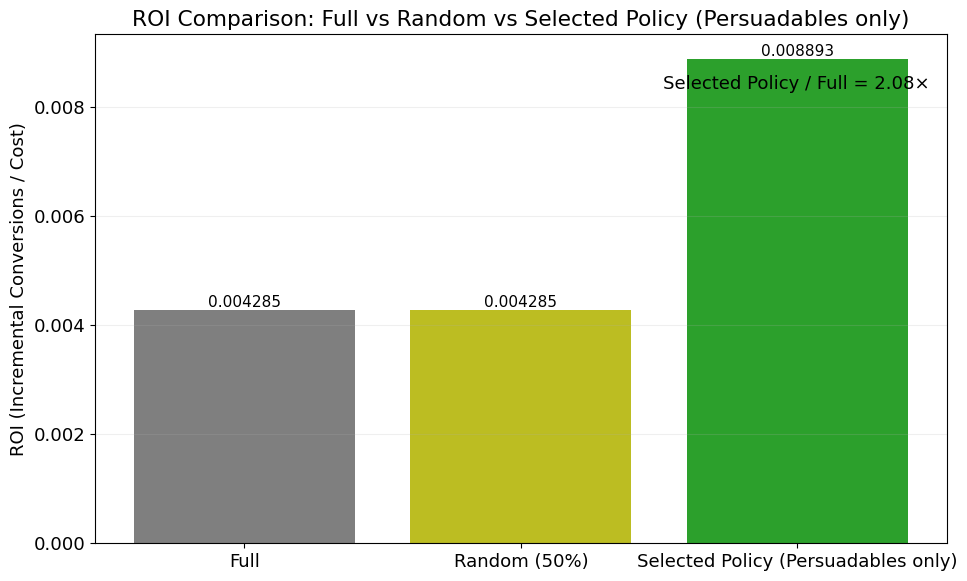

In [11]:
# ======================================================
# Section 3 (Cell 3/4): ROI Comparison
# ======================================================

full_roi = float(roi_results['full_targeting']['roi'])
prec_roi = float(roi_results['precision_targeting']['roi'])

# Random targeting @ 50%
random_50 = next((x for x in roi_results['random_targeting'] if abs(float(x['budget_pct']) - 0.5) < 1e-12), None)

assert random_50 is not None, 'random_targeting must include budget_pct=0.5'
rand_roi = float(random_50['roi'])

labels = ['Full', 'Random (50%)', 'Selected Policy (Persuadables only)']
values = [full_roi, rand_roi, prec_roi]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#7f7f7f', '#bcbd22', '#2ca02c'])
plt.ylabel('ROI (Incremental Conversions / Cost)')
plt.title('ROI Comparison: Full vs Random vs Selected Policy (Persuadables only)')
plt.grid(axis='y', alpha=0.20)

# Value labels
for b in bars:
    h = float(b.get_height())
    plt.text(b.get_x() + b.get_width() / 2, h, f"{h:.6f}", ha='center', va='bottom', fontsize=11)

# Annotation: precision vs full ratio
ratio = (prec_roi / full_roi) if abs(full_roi) > 1e-12 else float('inf')
plt.text(0.98, 0.92, f"Selected Policy / Full = {ratio:.2f}×", transform=plt.gca().transAxes, ha='right', va='top')

plt.tight_layout()
out = figures_dir / 'fig_08_roi_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()


.png saved: outputs\figures\fig_08b_budget_uplift_curve.png


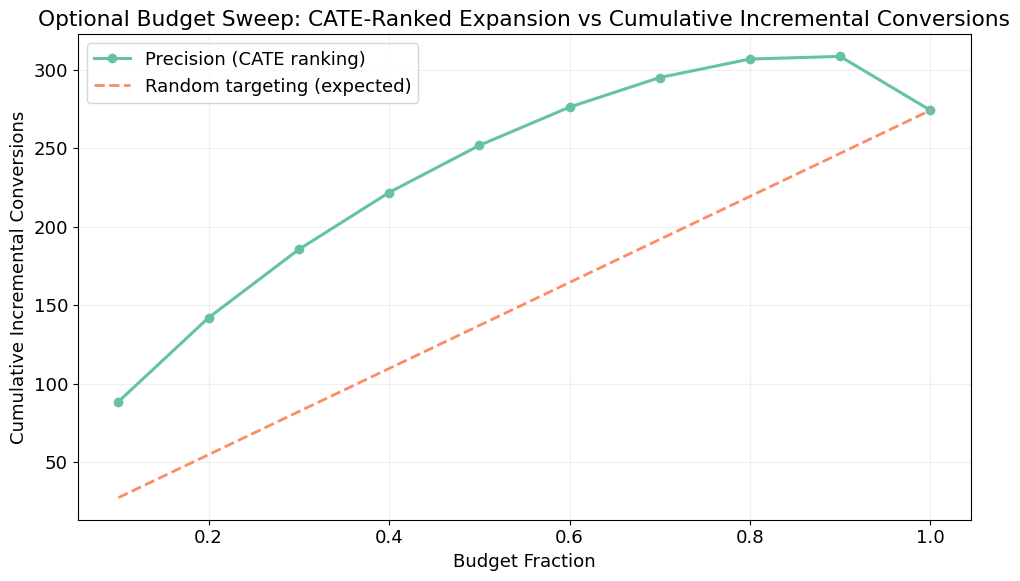

Optional budget-sweep result: continuous CATE expansion reaches ≥95% of full uplift at budget ≈ 60%
.json saved: data\processed\roi_simulation.json


In [14]:
# ======================================================
# Section 3 (Cell 4/4): Optional Budget Sweep (Upper-Bound Expansion Analysis)
# ======================================================

budget_sweep = roi_results['budget_sweep']
random_line = roi_results['random_targeting']

xs = [float(x['budget_pct']) for x in budget_sweep]
ys = [float(x['cumulative_uplift']) for x in budget_sweep]
rand_y = [float(x['n_incremental_conv']) for x in random_line]

assert xs[0] > 0 and xs[-1] == 1.0, 'budget_sweep x-axis must end at 1.0'

plt.figure(figsize=(10, 6))
plt.plot(xs, ys, marker='o', linewidth=2.2, label='Precision (CATE ranking)')
plt.plot(xs, rand_y, linestyle='--', linewidth=2.0, label='Random targeting (expected)')

plt.title('Optional Budget Sweep: CATE-Ranked Expansion vs Cumulative Incremental Conversions')
plt.xlabel('Budget Fraction')
plt.ylabel('Cumulative Incremental Conversions')
plt.grid(alpha=0.20)
plt.legend(loc='upper left')
plt.tight_layout()

out = figures_dir / 'fig_08b_budget_uplift_curve.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()

# Highlight: at what budget do we achieve ~full uplift?
full_uplift = float(roi_results['full_targeting']['n_incremental_conv'])
if full_uplift > 1e-12:
    best_idx = int(np.argmax(np.array(ys) / full_uplift >= 0.95)) if any((np.array(ys) / full_uplift) >= 0.95) else None
    if best_idx is not None:
        print(f"Optional budget-sweep result: continuous CATE expansion reaches ≥95% of full uplift at budget ≈ {xs[best_idx]*100:.0f}%")

# Persist ROI results
roi_out = Path('data') / 'processed' / 'roi_simulation.json'
roi_out.parent.mkdir(parents=True, exist_ok=True)
with open(roi_out, 'w', encoding='utf-8') as f:
    json.dump(roi_results, f, ensure_ascii=False, indent=2)
print(f'.json saved: {roi_out}')


## Section 4: Business Conclusion

In [13]:
# ======================================================
# Section 4 (Cell 1/1): Business conclusion (Markdown)
# ======================================================

full = roi_results['full_targeting']
prec = roi_results['precision_targeting']

full_n = int(full['n_targeted'])
prec_n = int(prec['n_targeted'])
budget_saving = float(prec['budget_saving_pct'])
retention = float(prec['conversion_retention_pct'])
roi_ratio = (float(prec['roi']) / float(full['roi'])) if abs(float(full['roi'])) > 1e-12 else float('inf')

seg_summary = (
    segments_df.groupby('segment', observed=True)
    .agg(count=('segment', 'size'), mean_cate=('cate', 'mean'))
    .assign(pct=lambda d: d['count'] / d['count'].sum() * 100.0)
    .reindex(['Persuadables', 'Sure Things', 'Lost Causes', 'Sleeping Dogs'])
)

p_pct = float(seg_summary.loc['Persuadables', 'pct']) if 'Persuadables' in seg_summary.index else float('nan')
st_pct = float(seg_summary.loc['Sure Things', 'pct']) if 'Sure Things' in seg_summary.index else float('nan')
sd_pct = float(seg_summary.loc['Sleeping Dogs', 'pct']) if 'Sleeping Dogs' in seg_summary.index else float('nan')

md = f"""
### 【核心商业结论（离线策略模拟）】

基于 Uplift Modeling 的精准投放策略（只投放 Persuadables），在离线策略模拟下，相比全量投放：

- 预计节省 **{budget_saving:.1f}%** 的营销预算（从 **{full_n:,}** 人缩减到 **{prec_n:,}** 人）
- 预计保留 **{retention:.1f}%** 的增量转化效果
- expected ROI proxy 提升 **{roi_ratio:.2f}×**

这意味着：如果把触达成本归一化为 100 个预算单位，精准投放预计可节省约 **{budget_saving:.0f}** 个单位，
同时预计保留约一半（{retention:.1f}%）的增量转化。该结论用于说明 relative efficiency，不等同真实财务预算表。

### 【四象限人群画像摘要】

- Persuadables (**{p_pct:.1f}%**)
- Sure Things (**{st_pct:.1f}%**)
- Sleeping Dogs (**{sd_pct:.1f}%**)

### 【业务建议】

1. 默认投放名单 = Persuadables only
2. 显式排除 Sleeping Dogs（避免负面效果）
3. Sure Things 与 Lost Causes 不纳入默认投放名单；若未来需要扩量，再单独测试
4. 建议每季度重新训练模型，更新人群分层；若未来引入 top-K / cutoff 扩量，应作为独立 extension 再验证
"""
display(Markdown(md))



### 【核心商业结论（离线策略模拟）】

基于 Uplift Modeling 的精准投放策略（只投放 Persuadables），在离线策略模拟下，相比全量投放：

- 预计节省 **75.0%** 的营销预算（从 **64,000** 人缩减到 **16,000** 人）
- 预计保留 **51.9%** 的增量转化效果
- expected ROI proxy 提升 **2.08×**

这意味着：如果把触达成本归一化为 100 个预算单位，精准投放预计可节省约 **75** 个单位，
同时预计保留约一半（51.9%）的增量转化。该结论用于说明 relative efficiency，不等同真实财务预算表。

### 【四象限人群画像摘要】

- Persuadables (**25.0%**)
- Sure Things (**25.0%**)
- Sleeping Dogs (**13.4%**)

### 【业务建议】

1. 默认投放名单 = Persuadables only
2. 显式排除 Sleeping Dogs（避免负面效果）
3. Sure Things 与 Lost Causes 不纳入默认投放名单；若未来需要扩量，再单独测试
4. 建议每季度重新训练模型，更新人群分层；若未来引入 top-K / cutoff 扩量，应作为独立 extension 再验证
